In [ ]:
#1. Khai báo thư viện:
import numpy as np
import cv2
from matplotlib import pyplot as plt

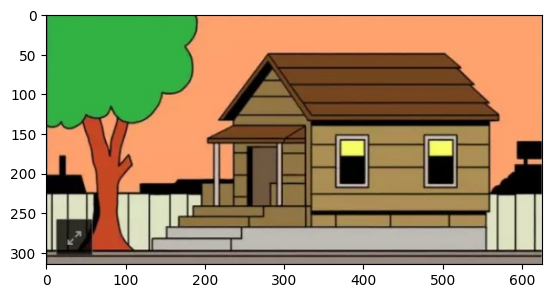

In [ ]:
# Kiểm tra opencv đọc ảnh và đặt ảnh cho đúng hiển thị ban đầu
img = cv2.imread('example.jpg')
plt.imshow(img[:,:,::-1])

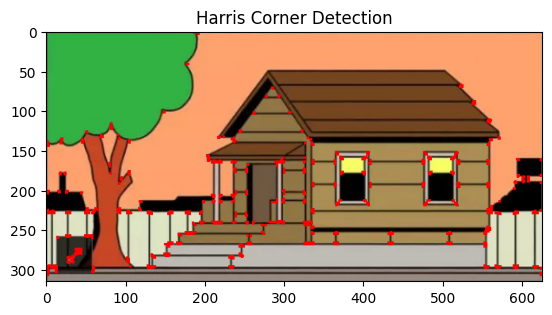

In [ ]:
#2. Sử dụng Harris Corner Detection tìm các keypoint trong ảnh.
img = cv2.imread('example.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray = np.float32(gray)
dst = cv2.cornerHarris(gray, 2, 3, 0.04)

dst = cv2.dilate(dst, None)

img[dst > 0.01 * dst.max()] = [0,0,255]

plt.imshow(img[:,:,::-1])
plt.title("Harris Corner Detection")
plt.show()

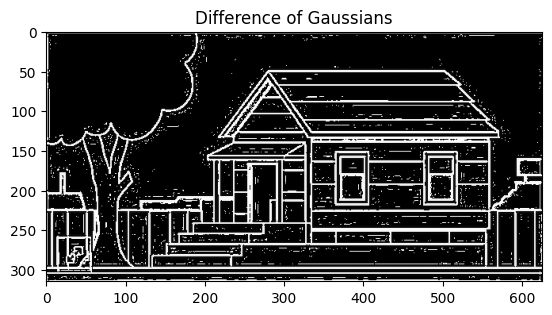

In [ ]:
#3. Sử dụng Band-pass filtering by Difference of Gaussians
img = cv2.imread('example.jpg',0)

g1 = cv2.GaussianBlur(img,(5,5),1)
g2 = cv2.GaussianBlur(img,(5,5),2)

dog = g1 - g2

plt.imshow(dog,cmap='gray')
plt.title("Difference of Gaussians")
plt.show()

In [ ]:
#4. Kiểm tra ảnh qua Automatic Scale Selection
img = cv2.imread('example.jpg',0)

sigmas = [1,2,4,8]

responses = []

for s in sigmas:
    blur = cv2.GaussianBlur(img,(0,0),s)
    lap = cv2.Laplacian(blur,cv2.CV_64F)
    responses.append(np.abs(lap).mean())

best_scale = sigmas[np.argmax(responses)]

print("Best scale:", best_scale)

Best scale: 1


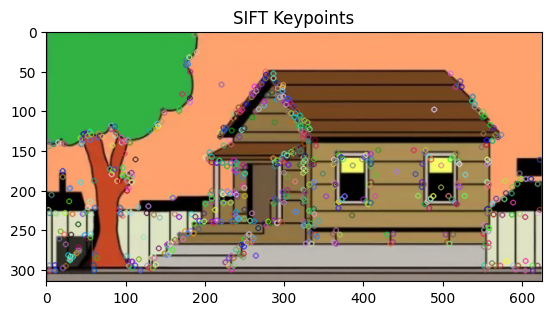

In [ ]:
#5. Kiểm tra ảnh qua Scale Invariant Detection
img = cv2.imread('example.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp,des = sift.detectAndCompute(gray,None)

img_kp = cv2.drawKeypoints(img,kp,None)

plt.imshow(img_kp[:,:,::-1])
plt.title("SIFT Keypoints")
plt.show()

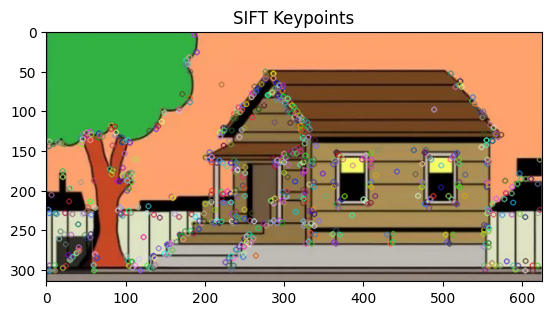

In [ ]:
#6. Kiểm tra ảnh qua Scale-space blob detector
img = cv2.imread('example.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp,des = sift.detectAndCompute(gray,None)

img_kp = cv2.drawKeypoints(img,kp,None)

plt.imshow(img_kp[:,:,::-1])
plt.title("SIFT Keypoints")
plt.show()

In [ ]:
#7. Thực hành với Bag-of-words detection
sift = cv2.SIFT_create()

img = cv2.imread('example.jpg',0)

kp,des = sift.detectAndCompute(img,None)

bow_trainer = cv2.BOWKMeansTrainer(50)

bow_trainer.add(des)

vocab = bow_trainer.cluster()

print("Vocabulary shape:", vocab.shape)

Vocabulary shape: (50, 128)


In [ ]:
#8. Ghép ảnh Image Panoramas
img1 = cv2.imread('example.jpg')
img2 = cv2.imread('lenna.png')

stitcher = cv2.Stitcher_create()

status, pano = stitcher.stitch([img1,img2])

if status == cv2.Stitcher_OK:
    plt.imshow(pano[:,:,::-1])
    plt.title("Panorama")
    plt.show()
else:
    print("Stitching failed")

Stitching failed


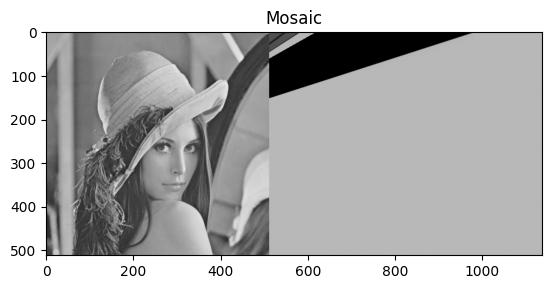

In [ ]:
#9. Ghép ảnh Automatic mosaicing
img1 = cv2.imread('example.jpg',0)
img2 = cv2.imread('lenna.png',0)

sift = cv2.SIFT_create()

kp1,des1 = sift.detectAndCompute(img1,None)
kp2,des2 = sift.detectAndCompute(img2,None)

bf = cv2.BFMatcher()

matches = bf.knnMatch(des1,des2,k=2)

good = []
for m,n in matches:
    if m.distance < 0.75*n.distance:
        good.append(m)

pts1 = np.float32([kp1[m.queryIdx].pt for m in good])
pts2 = np.float32([kp2[m.trainIdx].pt for m in good])

H,_ = cv2.findHomography(pts1,pts2,cv2.RANSAC)

result = cv2.warpPerspective(img1,H,(img2.shape[1]+img1.shape[1],img2.shape[0]))
result[0:img2.shape[0],0:img2.shape[1]] = img2

plt.imshow(result,cmap='gray')
plt.title("Mosaic")
plt.show()

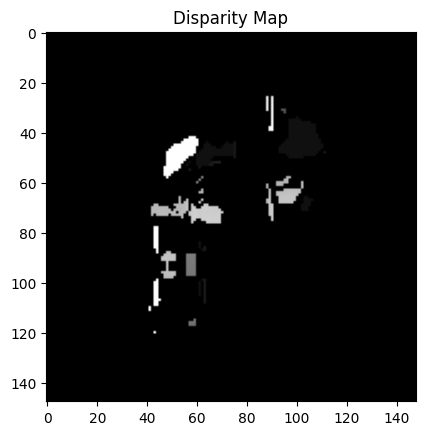

In [ ]:
#10. Sử dụng Wide base-line stereo
import cv2
from matplotlib import pyplot as plt

imgL = cv2.imread('left.jpg',0)
imgR = cv2.imread('right.jpg',0)

imgR = cv2.resize(imgR,(imgL.shape[1], imgL.shape[0]))

stereo = cv2.StereoBM_create(numDisparities=16, blockSize=15)

disparity = stereo.compute(imgL,imgR)

plt.imshow(disparity, cmap='gray')
plt.title("Disparity Map")
plt.show()

In [ ]:
#11. CBIR (content-based image retrieval)
import cv2
import numpy as np

img = cv2.imread("example.jpg",0)

sift = cv2.SIFT_create()

kp1,des1 = sift.detectAndCompute(img,None)

img2 = cv2.flip(img,1)

kp2,des2 = sift.detectAndCompute(img2,None)

bf = cv2.BFMatcher()

matches = bf.knnMatch(des1,des2,k=2)

good = []

for m,n in matches:
    if m.distance < 0.75*n.distance:
        good.append(m)

print("Matching features:",len(good))

Matching features: 198


In [ ]:
#12. Bag-of-word with SIFT + Histogram
import cv2
import numpy as np
import glob
from sklearn.cluster import KMeans

# 1. Tự động tìm ảnh trong folder
image_paths = glob.glob("*.jpg") + glob.glob("*.png") 

if len(image_paths) == 0:
    raise FileNotFoundError("Không tìm thấy ảnh nào. Hãy kiểm tra lại folder!")

sift = cv2.SIFT_create()
descriptor_list = []
valid_paths = []

print("Bước 1: Trích xuất descriptors...")
for path in image_paths:
    img = cv2.imread(path, 0)
    if img is None: continue
    
    kp, des = sift.detectAndCompute(img, None)
    if des is not None:
        descriptor_list.extend(des)
        valid_paths.append(path)

# Chuyển sang numpy array
descriptors = np.array(descriptor_list)

# KIỂM TRA DỮ LIỆU TRƯỚC KHI CLUSTERING
if descriptors.shape[0] < 40: # 40 là giá trị k
    print(f"Lỗi: Chỉ tìm thấy {descriptors.shape[0]} descriptors, không đủ để chia thành 40 cụm!")
else:
    # 2. Gom cụm (K-Means)
    k = 40
    print(f"Bước 2: Đang gom cụm {len(descriptors)} đặc trưng thành {k} từ điển...")
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(descriptors)

    # 3. Tạo Histogram cho từng ảnh
    print("Bước 3: Tạo Histogram...")
    histograms = []
    for path in valid_paths:
        img = cv2.imread(path, 0)
        kp, des = sift.detectAndCompute(img, None)
        
        hist = np.zeros(k)
        if des is not None:
            labels = kmeans.predict(des)
            for l in labels:
                hist[l] += 1
            # Chuẩn hóa (Normalization) để các ảnh to/nhỏ có giá trị tương đương
            hist = hist / np.sum(hist)
            
        histograms.append(hist)

    print("\nKết quả Histogram (mô tả đặc trưng ảnh):")
    print(np.array(histograms))

Bước 1: Trích xuất descriptors...
Bước 2: Đang gom cụm 1915 đặc trưng thành 40 từ điển...
Bước 3: Tạo Histogram...

Kết quả Histogram (mô tả đặc trưng ảnh):
[[0.00649351 0.02467532 0.01038961 0.08441558 0.01558442 0.01688312
  0.02467532 0.01298701 0.01688312 0.01818182 0.02207792 0.0025974
  0.03246753 0.06623377 0.02857143 0.01168831 0.04155844 0.00519481
  0.0987013  0.02077922 0.00519481 0.01298701 0.05064935 0.01688312
  0.02337662 0.01298701 0.02467532 0.0025974  0.0025974  0.05064935
  0.02727273 0.02467532 0.05714286 0.00779221 0.01428571 0.01558442
  0.01948052 0.03636364 0.0025974  0.03116883]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.16666667 0.16666667 0.
  0.         0.05555556 0.27777778 0.         0.         0.
  0.16666667 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.05555556 0.         0.         0.
  0.11111111 0.         0.   